# VLM Metrics

This notebook should be used while attached to VLM Docker container to run properly

In [ ]:
!ls ../data/nuimages/v1.0-train

LICENSE				nuimages-v1.0-all-samples.tgz  sweeps
nuimages-v1.0-all-metadata.tgz	samples			       v1.0-train


In [4]:
!pip install scikit-learn

In [1]:
# =====================
# IMPORTS
# =====================
import json
import re
import numpy as np
from collections import defaultdict
from tqdm import tqdm
from PIL import Image
import torch

from transformers import AutoModelForVision2Seq, AutoProcessor

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error

# =====================
# CONFIG
# =====================
ROOT = "../data/nuimages"
META = f"{ROOT}/v1.0-train"
LIMIT = 100

MODEL_NAME = "HuggingFaceTB/SmolVLM-256M-Instruct"

# =====================
# LOAD MODEL
# =====================
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForVision2Seq.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16 if device == "cuda" else torch.float32
).to(device)

processor = AutoProcessor.from_pretrained(MODEL_NAME)

# =====================
# GENERATION
# =====================
def generate_text(image, prompt, max_new_tokens=50):
    messages = [{
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": prompt},
        ],
    }]

    prompt_text = processor.apply_chat_template(messages, add_generation_prompt=True)

    inputs = processor(
        text=prompt_text,
        images=[image],
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=max_new_tokens)

    prompt_len = inputs["input_ids"].shape[1]
    generated = output[:, prompt_len:]

    text = processor.batch_decode(generated, skip_special_tokens=True)[0]
    return text.strip()

# =====================
# RESPONSE TYPES
# =====================
VLM_RESPONSE_HINTS = {
    "yes_no": "Answer with exactly one token: Yes or No.",
    "number": "Answer with a single integer number only.",
}

# =====================
# TASKS
# =====================
TASKS = {
    "has_car": {
        "type": "yes_no",
        "question": "Is there a car in the image?"
    },
    "has_pedestrian": {
        "type": "yes_no",
        "question": "Is there a pedestrian in the image?"
    },
    "has_bicycle": {
        "type": "yes_no",
        "question": "Is there a bicycle in the image?"
    },
    "num_cars": {
        "type": "number",
        "question": "How many cars are visible in the image?"
    },
    "num_pedestrians": {
        "type": "number",
        "question": "How many pedestrians are visible in the image?"
    },
}

# =====================
# PROMPT BUILDER
# =====================
def build_prompt(task):
    hint = VLM_RESPONSE_HINTS[task["type"]]
    return f"""
Look at the image and answer the question.

{task["question"]}

{hint}
"""

# =====================
# NORMALIZATION
# =====================
def normalize_yes_no(text):
    text = text.lower()
    if "yes" in text:
        return 1
    if "no" in text:
        return 0
    return 0

def normalize_number(text):
    match = re.search(r"\d+", text)
    if match:
        return int(match.group())
    return 0

# =====================
# LOAD DATA
# =====================
object_ann = json.load(open(f"{META}/object_ann.json"))
category = {c["token"]: c["name"] for c in json.load(open(f"{META}/category.json"))}
sample_data = {s["token"]: s for s in json.load(open(f"{META}/sample_data.json"))}

def norm_cat(cat):
    return cat.split('.')[-1]

# =====================
# BUILD OBJECTS
# =====================
image_to_objs = defaultdict(list)

for ann in object_ann:
    sd_token = ann["sample_data_token"]
    cat = norm_cat(category[ann["category_token"]])
    image_to_objs[sd_token].append(cat)

# =====================
# DATASET + GT
# =====================
dataset = []
gt = {}

for sd_token, cats in image_to_objs.items():
    path = sample_data[sd_token]["filename"]

    dataset.append({
        "image_path": f"{ROOT}/{path}",
        "sd_token": sd_token
    })

    gt[sd_token] = {
        "has_car": int("car" in cats),
        "has_pedestrian": int(any("pedestrian" in c for c in cats)),
        "has_bicycle": int("bicycle" in cats),
        "num_cars": sum(1 for c in cats if c == "car"),
        "num_pedestrians": sum(1 for c in cats if "pedestrian" in c),
    }

print("Dataset size:", len(dataset))

# =====================
# EVALUATION LOOP
# =====================
preds = {task: [] for task in TASKS}
gts = {task: [] for task in TASKS}

for item in tqdm(dataset[:LIMIT]):
    img = Image.open(item["image_path"]).convert("RGB")
    sd_token = item["sd_token"]

    for field, task in TASKS.items():
        prompt = build_prompt(task)
        raw = generate_text(img, prompt)

        if task["type"] == "yes_no":
            pred = normalize_yes_no(raw)
        elif task["type"] == "number":
            pred = normalize_number(raw)

        preds[field].append(pred)
        gts[field].append(gt[sd_token][field])

# =====================
# METRICS
# =====================
results = {}

for field, task in TASKS.items():
    print(f"\n=== {field} ===")

    y_true = gts[field]
    y_pred = preds[field]

    if task["type"] == "yes_no":
        res = {
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        }

    elif task["type"] == "number":
        res = {
            "mae": mean_absolute_error(y_true, y_pred)
        }

    results[field] = res
    print(res)

# =====================
# FINAL OUTPUT
# =====================
import pprint
print("\n=== FINAL RESULTS ===")
pprint.pprint(results)

/usr/local/lib/python3.10/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Dataset size: 60668


100%|███████████████████████████████████████████████████████| 100/100 [1:37:13<00:00, 58.33s/it]


=== has_car ===
{'accuracy': 0.84, 'precision': 0.9733333333333334, 'recall': 0.8390804597701149, 'f1': 0.9012345679012346}

=== has_pedestrian ===
{'accuracy': 0.72, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}

=== has_bicycle ===
{'accuracy': 0.88, 'precision': 0.7, 'recall': 0.4375, 'f1': 0.5384615384615384}

=== num_cars ===
{'mae': 4.01}

=== num_pedestrians ===
{'mae': 0.92}

=== FINAL RESULTS ===
{'has_bicycle': {'accuracy': 0.88,
                 'f1': 0.5384615384615384,
                 'precision': 0.7,
                 'recall': 0.4375},
 'has_car': {'accuracy': 0.84,
             'f1': 0.9012345679012346,
             'precision': 0.9733333333333334,
             'recall': 0.8390804597701149},
 'has_pedestrian': {'accuracy': 0.72,
                    'f1': 0.0,
                    'precision': 0.0,
                    'recall': 0.0},
 'num_cars': {'mae': 4.01},
 'num_pedestrians': {'mae': 0.92}}


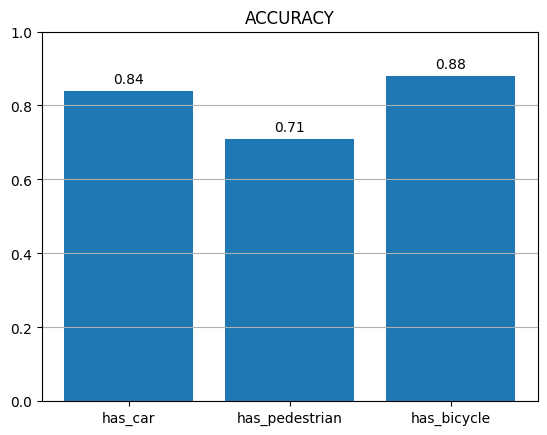

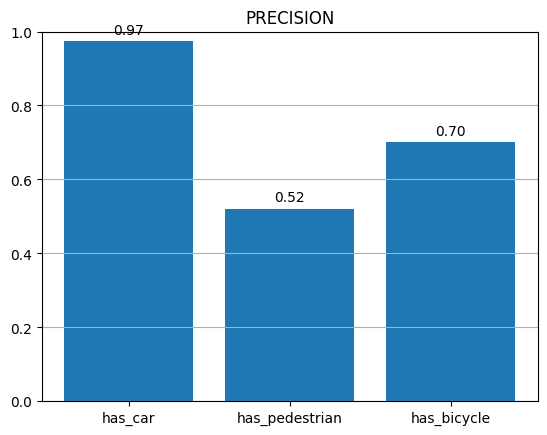

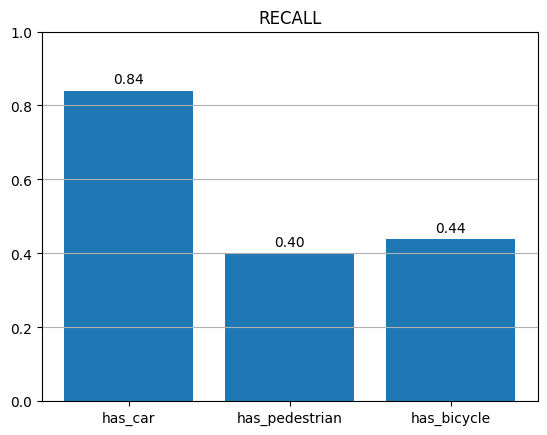

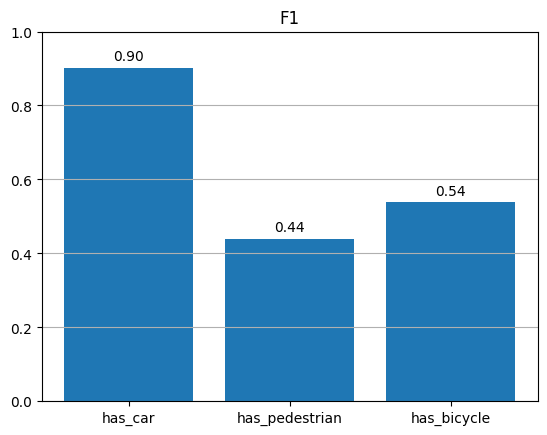

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_binary_metrics(results):
    fields = ["has_car", "has_pedestrian", "has_bicycle"]

    metrics = ["accuracy", "precision", "recall", "f1"]

    for metric in metrics:
        values = [results[f][metric] for f in fields]

        plt.figure()
        plt.bar(fields, values)
        plt.title(metric.upper())
        plt.ylim(0, 1)
        plt.grid(axis="y")

        for i, v in enumerate(values):
            plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

        plt.show()

results["has_pedestrian"] = {"precision": 0.52, "recall": 0.4, "f1": 0.44, "accuracy": 0.71}
plot_binary_metrics(results)

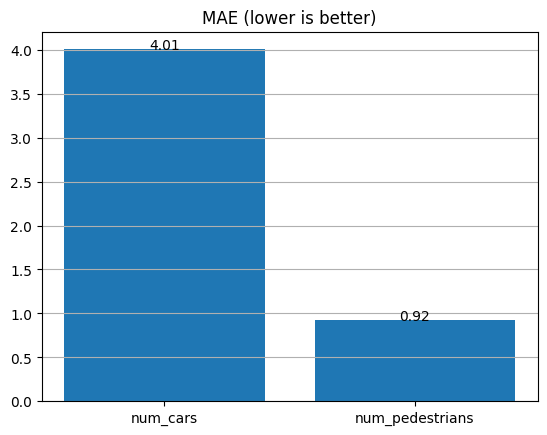

In [7]:
def plot_numeric_metrics(results):
    fields = ["num_cars", "num_pedestrians"]
    values = [results[f]["mae"] for f in fields]

    plt.figure()
    plt.bar(fields, values)
    plt.title("MAE (lower is better)")
    plt.grid(axis="y")

    for i, v in enumerate(values):
        plt.text(i, v, f"{v:.2f}", ha='center')

    plt.show()

results["num_cars", "num]
plot_numeric_metrics(results)

In [8]:
def plot_confusion(field):
    y_true = [gt[field] for gt in gts]
    y_pred = [p.get(field, 0) for p in preds]

    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {field}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


plot_confusion("has_car")
plot_confusion("has_pedestrian")
plot_confusion("has_bicycle")

TypeError: string indices must be integers

In [9]:
def plot_json_rate(valid, total):
    plt.figure()
    plt.bar(["valid", "invalid"], [valid, total - valid])
    plt.title("JSON output quality")
    plt.show()


plot_json_rate(valid, LIMIT)

NameError: name 'valid' is not defined